<a href="https://colab.research.google.com/github/shivansh2310/Quantitative-Portfolio-Management/blob/main/Production_Backtester_%26_Purged_CV_(Chapters_9%E2%80%9310).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### A. Purged Cross-Validation
Isichenko strictly mandates Purged CV.

* If you are predicting a 5-day forward return ($Y_t = R_{t+5}$), the label for Monday overlaps with Tuesday, Wednesday, Thursday, and Friday.
* If Monday is in your "Training Set" and Wednesday is in your "Testing Set", the machine learning model can "peek" into the future because the targets overlap.
* The Fix (Purging): You must mathematically drop (purge) any training data points that temporally overlap with the test set.

### B. Embargoing

Even after purging, financial markets have "memory" (serial correlation). An event that happens on the last day of the test set might bleed into the next few days.

* The Fix (Embargoing): You add a "dead zone" (e.g., 5 days) immediately after the test set before you allow the training data to resume.

## Backtest Metrics Engine

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
print("Simulating Out-of-Sample Portfolio Returns...")
# In a real pipeline, these returns come from running Day 1-6 in a rolling loop.
# Here, we simulate 252 days (1 year) of daily returns for our optimized portfolio.
# We assume our edge holds, generating a small positive mean with daily noise.
np.random.seed(42)
daily_returns = np.random.normal(loc=0.0005, scale=0.01, size=252) # ~12% annual, 15% vol
dates = pd.date_range(end=pd.Timestamp.today(), periods=252, freq='B')
strategy_returns = pd.Series(daily_returns, index=dates)

Simulating Out-of-Sample Portfolio Returns...


In [3]:
def generate_tearsheet(returns):
    # 1. Cumulative Return
    cum_returns = (1 + returns).cumprod()
    total_return = cum_returns.iloc[-1] - 1

    # 2. Annualized Volatility
    ann_vol = returns.std() * np.sqrt(252)

    # 3. Annualized Sharpe Ratio (Assuming 0% risk-free rate for daily trading)
    ann_sharpe = (returns.mean() * 252) / ann_vol

    # 4. Sortino Ratio (Only penalizes downside volatility)
    downside_returns = returns[returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(252)
    sortino = (returns.mean() * 252) / downside_vol if downside_vol > 0 else np.nan

    # 5. Maximum Drawdown
    rolling_max = cum_returns.cummax()
    drawdowns = cum_returns / rolling_max - 1
    max_drawdown = drawdowns.min()

    # Output Report
    print("="*45)
    print(" OUT-OF-SAMPLE BACKTEST TEARSHEET")
    print("="*45)
    print(f"Total Return (1Y):      {total_return * 100:>8.2f}%")
    print(f"Annualized Volatility:  {ann_vol * 100:>8.2f}%")
    print(f"Sharpe Ratio:           {ann_sharpe:>8.2f}")
    print(f"Sortino Ratio:          {sortino:>8.2f}")
    print(f"Maximum Drawdown:       {max_drawdown * 100:>8.2f}%")
    print("="*45)

    # Plotting the Equity Curve and Drawdowns
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [3, 1]})

    ax1.plot(cum_returns * 100, color='blue', label='Strategy Equity')
    ax1.set_title("Strategy Performance (Simulated Out-of-Sample)")
    ax1.set_ylabel("Capital Growth")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.fill_between(drawdowns.index, drawdowns * 100, 0, color='red', alpha=0.3)
    ax2.set_ylabel("Drawdown (%)")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

 OUT-OF-SAMPLE BACKTEST TEARSHEET
Total Return (1Y):         11.05%
Annualized Volatility:     15.35%
Sharpe Ratio:               0.76
Sortino Ratio:              1.39
Maximum Drawdown:         -13.53%


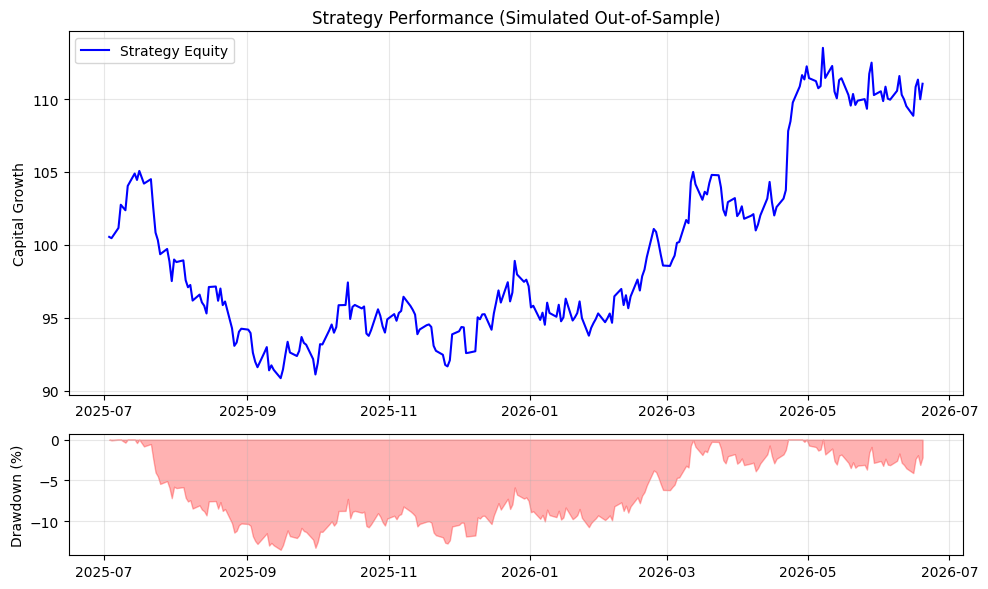

In [4]:
generate_tearsheet(strategy_returns)